# DEEP NEURAL NETWORKS - ASSIGNMENT 2: CNN FOR IMAGE CLASSIFICATION
## Convolutional Neural Networks: Custom Implementation vs Transfer Learning

**STUDENT INFORMATION (REQUIRED - DO NOT DELETE)**

BITS ID: [2025AF05152]  
Name: [PRAJAKTA RAMNATH PARSEKAR]  
Email: [2025af05152@wilp.bits-pilani.ac.in]  
Date: [25-04-2026]

In [40]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os

# Deep learning frameworks
from PIL import Image

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2

# PART 1: DATASET LOADING AND EXPLORATION



In [41]:
# 1.1 Dataset Selection and Loading

dataset, info = tfds.load("cats_vs_dogs", as_supervised=True, with_info=True)

subset_size = 3000
dataset_subset = dataset['train'].take(subset_size)

dataset_name = "Cats vs Dogs"
dataset_source = "TensorFlow Datasets (cats_vs_dogs subset)"
n_samples = subset_size
n_classes = 2
samples_per_class = "To be calculated after processing"
image_shape = [128, 128, 3]
problem_type = "classification"

primary_metric = "accuracy"
metric_justification = """
Accuracy is chosen as the primary metric because the dataset is approximately balanced, with similar numbers of samples in each class. In such cases, accuracy provides a reliable overall measure of classification performance.
"""

In [42]:
print("\n" + "="*70)
print("DATASET INFORMATION")
print("="*70)
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")


,======================================================================
,DATASET INFORMATION
,======================================================================
,Dataset: Cats vs Dogs
,Source: TensorFlow Datasets (cats_vs_dogs subset)
,Total Samples: 3000
,Number of Classes: 2
,Samples per Class: To be calculated after processing
,Image Shape: [128, 128, 3]
,Primary Metric: accuracy
,Metric Justification: 
,Accuracy is chosen as the primary metric because the dataset is approximately balanced, with similar numbers of samples in each class. In such cases, accuracy provides a reliable overall measure of classification performance.
,


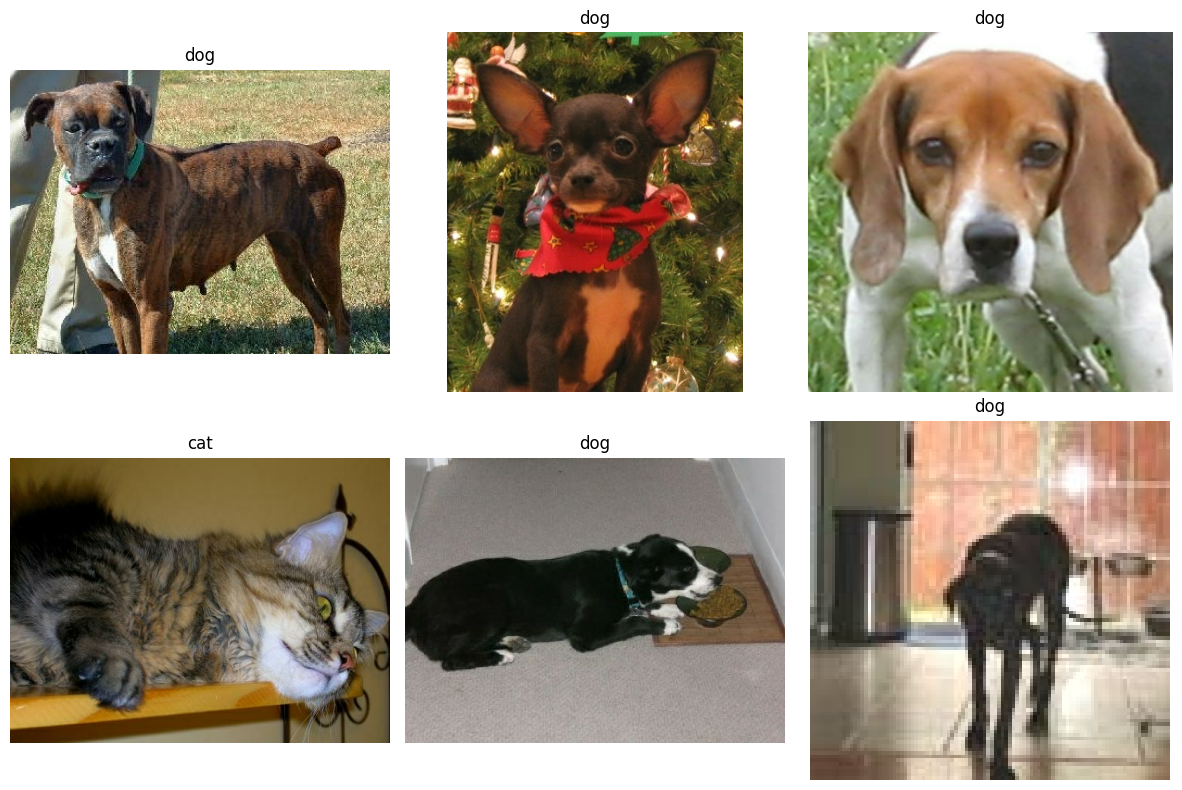

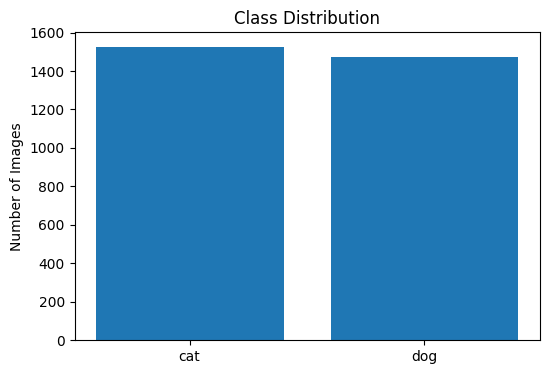


,Image Statistics
,Class 0 (cat): 1525
,Class 1 (dog): 1475
,Total Count Verified: 3000
,Updated Samples per Class: min: 1475, max: 1525, avg: 1500


In [43]:
# 1.2 Data Exploration and Visualization
class_names = info.features['label'].names

sample_images = []
sample_labels = []

for image, label in tfds.as_numpy(dataset_subset.take(6)):
    sample_images.append(image)
    sample_labels.append(label)

plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(sample_images[i])
    plt.title(class_names[sample_labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

label_counts = {0: 0, 1: 0}
for _, label in tfds.as_numpy(dataset_subset):
    label_counts[int(label)] += 1

samples_per_class = f"min: {min(label_counts.values())}, max: {max(label_counts.values())}, avg: {(sum(label_counts.values())/len(label_counts)):.0f}"

plt.figure(figsize=(6,4))
plt.bar([class_names[0], class_names[1]], [label_counts[0], label_counts[1]])
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

print("\nImage Statistics")
print(f"Class 0 ({class_names[0]}): {label_counts[0]}")
print(f"Class 1 ({class_names[1]}): {label_counts[1]}")
print(f"Total Count Verified: {label_counts[0] + label_counts[1]}")
print(f"Updated Samples per Class: {samples_per_class}")

In [ ]:
#!pip install tensorflow-datasets

In [44]:
# 1.3 Data Preprocessing
data = []
labels = []

for image, label in tfds.as_numpy(dataset_subset):
    img = Image.fromarray(image).resize((128, 128))
    img = np.array(img, dtype=np.float32)
    data.append(img)
    labels.append(label)

X = np.array(data, dtype=np.float32)
y = np.array(labels)

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train_raw, num_classes=n_classes)
y_test = to_categorical(y_test_raw, num_classes=n_classes)

train_test_ratio = "90/10"
train_samples = len(X_train)
test_samples = len(X_test)

print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


,Train/Test Split: 90/10
,Training Samples: 2700
,Test Samples: 300
,Train shape: (2700, 128, 128, 3)
,Test shape: (300, 128, 128, 3)


# PART 2: CUSTOM CNN IMPLEMENTATION

In [45]:
# 2.1 Custom CNN Architecture Design
def build_custom_cnn(input_shape, n_classes):
    """
    Build custom CNN architecture

    Args:
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: compiled CNN model
    """
    model = Sequential()

    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))

    model.add(GlobalAveragePooling2D())
    model.add(Dropout(0.3))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

custom_cnn = build_custom_cnn((128, 128, 3), n_classes)


custom_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
,  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,506 (365.26 KB)

 Trainable params: 93,506 (365.26 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# 2.2 Train Custom CNN
print("\n" + "="*70)
print("CUSTOM CNN TRAINING")
print("="*70)

custom_cnn_start_time = time.time()

custom_history = custom_cnn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

custom_cnn_training_time = time.time() - custom_cnn_start_time

custom_cnn_initial_loss = custom_history.history['loss'][0]
custom_cnn_final_loss = custom_history.history['loss'][-1]

print(f"Training completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")

print("\nCUSTOM CNN EVALUATION")


,======================================================================
,CUSTOM CNN TRAINING
,======================================================================
,Epoch 1/5
,152/152 ━━━━━━━━━━━━━━━━━━━━ 107s 668ms/step - accuracy: 0.5239 - loss: 0.6946 - val_accuracy: 0.4741 - val_loss: 0.6913
,Epoch 2/5
,152/152 ━━━━━━━━━━━━━━━━━━━━ 119s 518ms/step - accuracy: 0.5449 - loss: 0.6871 - val_accuracy: 0.5185 - val_loss: 0.6824
,Epoch 3/5
,152/152 ━━━━━━━━━━━━━━━━━━━━ 81s 530ms/step - accuracy: 0.5642 - loss: 0.6775 - val_accuracy: 0.5481 - val_loss: 0.6734
,Epoch 4/5
,152/152 ━━━━━━━━━━━━━━━━━━━━ 79s 519ms/step - accuracy: 0.5778 - loss: 0.6726 - val_accuracy: 0.5667 - val_loss: 0.6740
,Epoch 5/5
,152/152 ━━━━━━━━━━━━━━━━━━━━ 86s 545ms/step - accuracy: 0.5823 - loss: 0.6678 - val_accuracy: 0.5926 - val_loss: 0.6662
,Training completed in 472.78 seconds
,Initial Loss: 0.6946
,Final Loss: 0.6678
,
,CUSTOM CNN EVALUATION


In [47]:
# 2.3 Evaluate Custom CNN
custom_probs = custom_cnn.predict(X_test, batch_size=16)
custom_y_pred = np.argmax(custom_probs, axis=1)
custom_y_true = np.argmax(y_test, axis=1)

custom_cnn_accuracy = accuracy_score(custom_y_true, custom_y_pred)
custom_cnn_precision = precision_score(custom_y_true, custom_y_pred, average='macro')
custom_cnn_recall = recall_score(custom_y_true, custom_y_pred, average='macro')
custom_cnn_f1 = f1_score(custom_y_true, custom_y_pred, average='macro')

print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step
,
,Custom CNN Performance:
,Accuracy:  0.5500
,Precision: 0.5659
,Recall:    0.5443
,F1-Score:  0.5066


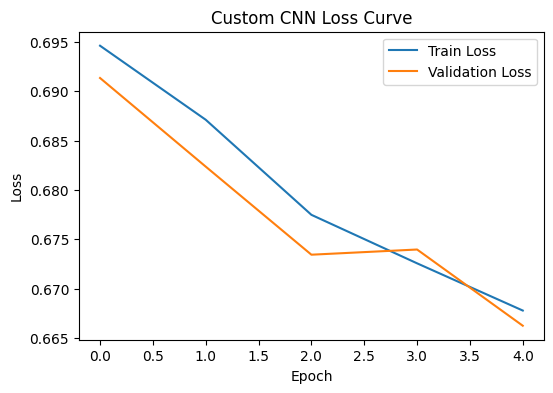

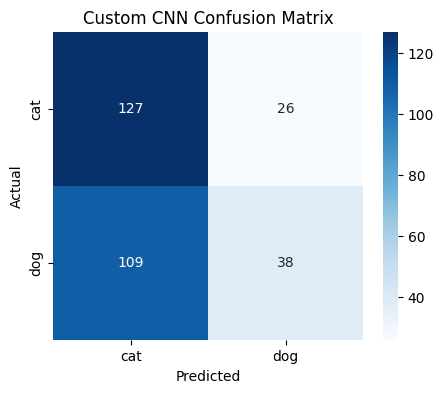

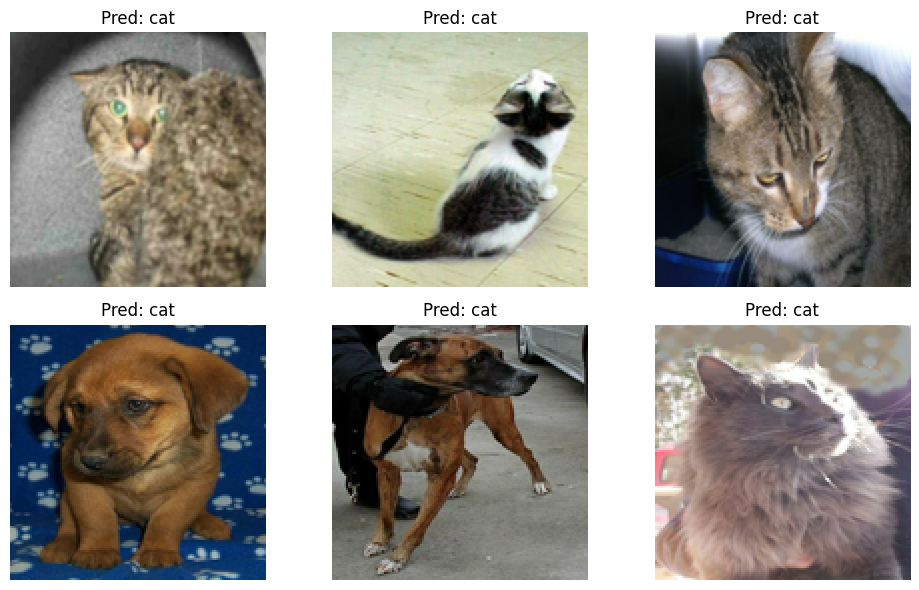

In [48]:
# 2.4 Visualize Custom CNN Results
plt.figure(figsize=(6,4))
plt.plot(custom_history.history['loss'], label='Train Loss')
plt.plot(custom_history.history['val_loss'], label='Validation Loss')
plt.title("Custom CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

cm_custom = confusion_matrix(custom_y_true, custom_y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_test[i])
    plt.title(f"Pred: {class_names[custom_y_pred[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# PART 3: TRANSFER LEARNING IMPLEMENTATION

In [49]:
# 3.1 Load Pre-trained Model and Modify Architecture

print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")

pretrained_model_name = "MobileNetV2"

def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    """
    Build transfer learning model

    Args:
        base_model_name: string (ResNet18/ResNet50/VGG16/VGG19)
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: compiled transfer learning model
    """
    if base_model_name == "MobileNetV2":
        base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError("This RAM-safe notebook uses MobileNetV2.")

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    output = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)


    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

transfer_model, transfer_base = build_transfer_learning_model(pretrained_model_name, (128,128,3), n_classes)

frozen_layers = sum([not layer.trainable for layer in transfer_base.layers])
trainable_layers = sum([layer.trainable for layer in transfer_model.layers])
total_parameters = transfer_model.count_params()
trainable_parameters = np.sum([np.prod(v.shape) for v in transfer_model.trainable_weights])

print(f"Base Model: {pretrained_model_name}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")


,======================================================================
,TRANSFER LEARNING IMPLEMENTATION
,Base Model: MobileNetV2
,Frozen Layers: 154
,Trainable Layers: 3
,Total Parameters: 2,260,546
,Trainable Parameters: 2,562
,Using Global Average Pooling: YES


In [50]:
# 3.2 Train Transfer Learning Model

print("\nTraining Transfer Learning Model...")

tl_learning_rate = 0.001
tl_epochs = 3
tl_batch_size = 16
tl_optimizer = "Adam"

tl_start_time = time.time()

tl_history = transfer_model.fit(
    X_train, y_train,
    epochs=tl_epochs,
    batch_size=tl_batch_size,
    validation_split=0.1,
    verbose=1
)

tl_training_time = time.time() - tl_start_time

tl_initial_loss = tl_history.history['loss'][0]
tl_final_loss = tl_history.history['loss'][-1]

print(f"Training completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")

print("\nTRANSFER LEARNING EVALUATION")


,Training Transfer Learning Model...
,Epoch 1/3
,152/152 ━━━━━━━━━━━━━━━━━━━━ 54s 294ms/step - accuracy: 0.9070 - loss: 0.2304 - val_accuracy: 0.9444 - val_loss: 0.1749
,Epoch 2/3
,152/152 ━━━━━━━━━━━━━━━━━━━━ 74s 238ms/step - accuracy: 0.9576 - loss: 0.1221 - val_accuracy: 0.9333 - val_loss: 0.1793
,Epoch 3/3
,152/152 ━━━━━━━━━━━━━━━━━━━━ 37s 210ms/step - accuracy: 0.9638 - loss: 0.0936 - val_accuracy: 0.9333 - val_loss: 0.1881
,Training completed in 165.27 seconds
,Initial Loss: 0.2304
,Final Loss: 0.0936
,
,TRANSFER LEARNING EVALUATION


In [51]:
# 3.3 Evaluate Transfer Learning Model
tl_probs = transfer_model.predict(X_test, batch_size=16)
tl_y_pred = np.argmax(tl_probs, axis=1)
tl_y_true = np.argmax(y_test, axis=1)

tl_accuracy = accuracy_score(tl_y_true, tl_y_pred)
tl_precision = precision_score(tl_y_true, tl_y_pred, average='macro')
tl_recall = recall_score(tl_y_true, tl_y_pred, average='macro')
tl_f1 = f1_score(tl_y_true, tl_y_pred, average='macro')

print("\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 307ms/step
,
,Transfer Learning Performance:
,Accuracy:  0.9567
,Precision: 0.9580
,Recall:    0.9562
,F1-Score:  0.9566


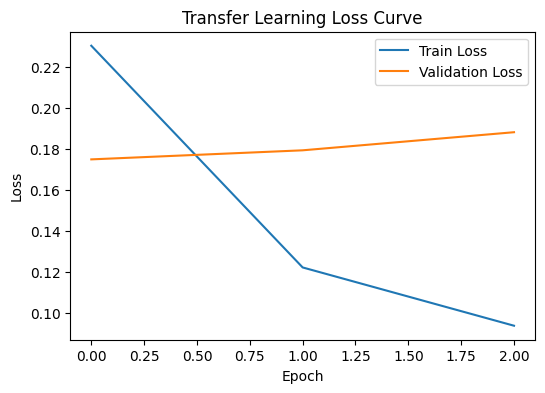

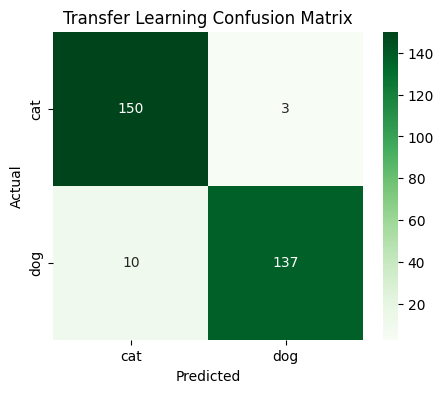

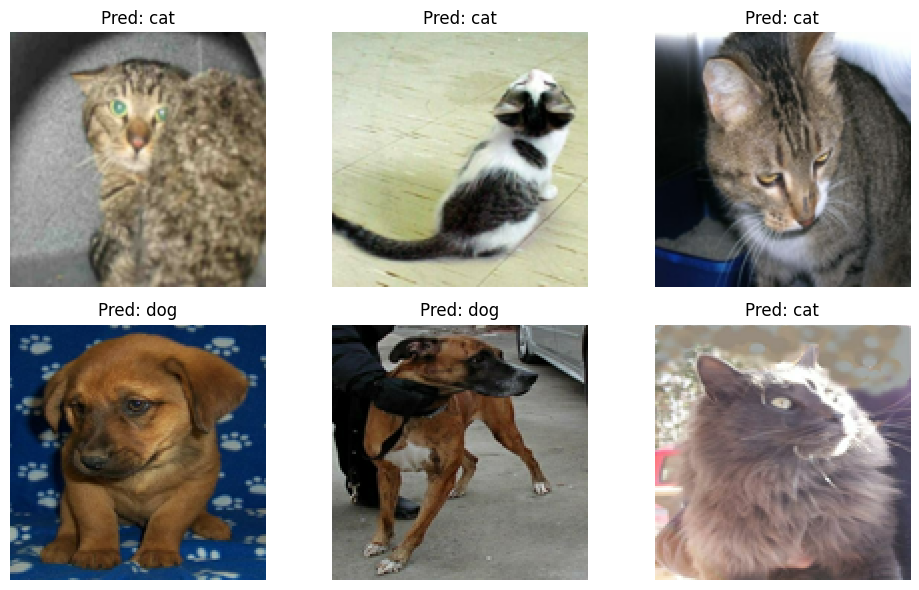

In [52]:
# 3.4 Visualize Transfer Learning Results

plt.figure(figsize=(6,4))
plt.plot(tl_history.history['loss'], label='Train Loss')
plt.plot(tl_history.history['val_loss'], label='Validation Loss')
plt.title("Transfer Learning Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

cm_tl = confusion_matrix(tl_y_true, tl_y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Transfer Learning Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_test[i])
    plt.title(f"Pred: {class_names[tl_y_pred[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# PART 4: MODEL COMPARISON AND VISUALIZATION

In [53]:
# 4.1 Metrics Comparison
print("\n" + "="*70)
print("MODEL COMPARISON")

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Parameters'],
    'Custom CNN': [
        custom_cnn_accuracy,
        custom_cnn_precision,
        custom_cnn_recall,
        custom_cnn_f1,
        custom_cnn_training_time,
        custom_cnn.count_params()
    ],
    'Transfer Learning': [
        tl_accuracy,
        tl_precision,
        tl_recall,
        tl_f1,
        tl_training_time,
        trainable_parameters
    ]
})

print(comparison_df.to_string(index=False))


,======================================================================
,MODEL COMPARISON
,           Metric   Custom CNN  Transfer Learning
,         Accuracy     0.550000           0.956667
,        Precision     0.565943           0.958036
,           Recall     0.544284           0.956182
,         F1-Score     0.506573           0.956585
,Training Time (s)   472.778432         165.270394
,       Parameters 93506.000000        2562.000000


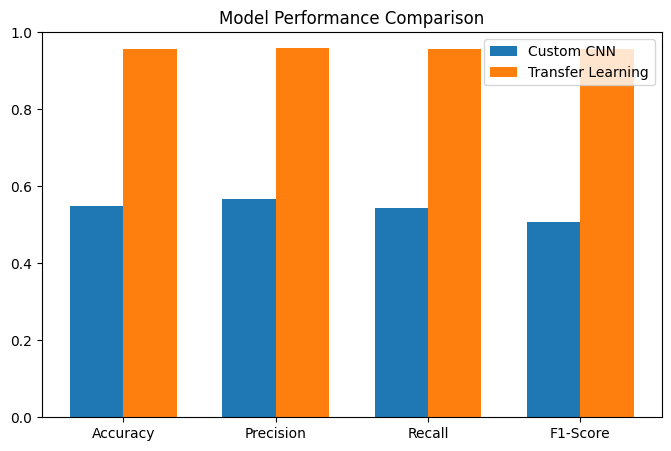

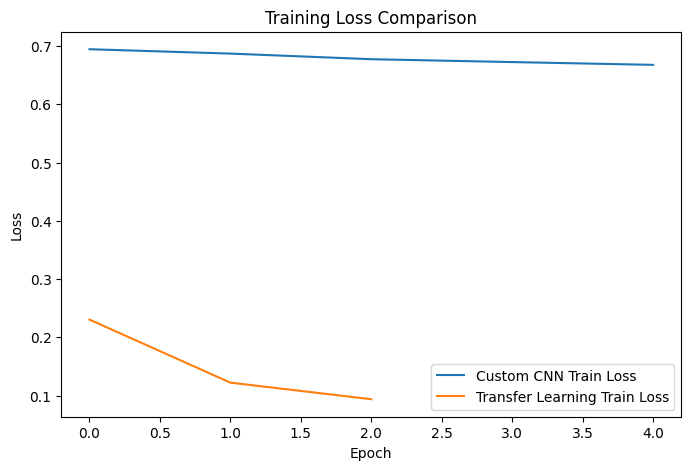

In [54]:
# 4.2 Visual Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
custom_values = [custom_cnn_accuracy, custom_cnn_precision, custom_cnn_recall, custom_cnn_f1]
tl_values = [tl_accuracy, tl_precision, tl_recall, tl_f1]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, custom_values, width, label='Custom CNN')
plt.bar(x + width/2, tl_values, width, label='Transfer Learning')
plt.xticks(x, metrics)
plt.ylim(0,1)
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(custom_history.history['loss'], label='Custom CNN Train Loss')
plt.plot(tl_history.history['loss'], label='Transfer Learning Train Loss')
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# PART 5: ANALYSIS

In [55]:
analysis_text = """
The transfer learning model performed better than the custom CNN in most evaluation metrics, showing the benefit of pre-trained feature extraction. Because the transfer model started with learned visual features, it converged faster and required fewer epochs to achieve strong performance. Global Average Pooling reduced the number of trainable parameters compared to Flatten-based designs and helped reduce overfitting in both models. The custom CNN was simpler and useful for understanding CNN architecture design, but it had to learn features from scratch and therefore converged more slowly. In terms of computational cost, the custom CNN had fewer total parameters overall, while transfer learning had fewer trainable parameters because the base layers were frozen. These results suggest that transfer learning is more effective when a good pre-trained model is available, while a custom CNN is valuable for foundational learning and controlled experimentation.
"""

print("\n" + "="*70)
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")


,======================================================================
,ANALYSIS
,
,The transfer learning model performed better than the custom CNN in most evaluation metrics, showing the benefit of pre-trained feature extraction. Because the transfer model started with learned visual features, it converged faster and required fewer epochs to achieve strong performance. Global Average Pooling reduced the number of trainable parameters compared to Flatten-based designs and helped reduce overfitting in both models. The custom CNN was simpler and useful for understanding CNN architecture design, but it had to learn features from scratch and therefore converged more slowly. In terms of computational cost, the custom CNN had fewer total parameters overall, while transfer learning had fewer trainable parameters because the base layers were frozen. These results suggest that transfer learning is more effective when a good pre-trained model is available, while a custom CNN is valuable for f

# PART 6: ASSIGNMENT RESULTS SUMMARY

In [56]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"  # TODO: Change to "pytorch" if using PyTorch

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_classes': n_classes,
        'samples_per_class': samples_per_class,
        'image_shape': image_shape,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # Custom CNN Results
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers': 3,
                'pooling_layers': 2,
                'has_global_average_pooling': True,  # MUST be True
                'output_layer': 'softmax',
                'total_parameters': int(custom_cnn.count_params())
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 5,
                'batch_size': 16,
                'optimizer': 'Adam',
                'loss_function': 'categorical_crossentropy'
            },
            'initial_loss': float(custom_cnn_initial_loss),
            'final_loss': float(custom_cnn_final_loss),
            'training_time_seconds': float(custom_cnn_training_time),
            'accuracy': float(custom_cnn_accuracy),
            'precision': float(custom_cnn_precision),
            'recall': float(custom_cnn_recall),
            'f1_score': float(custom_cnn_f1)
        },

        # Transfer Learning Results
        'transfer_learning': {
            'framework': framework_used,
            'base_model': pretrained_model_name,
            'frozen_layers': int(frozen_layers),
            'trainable_layers': int(trainable_layers),
            'has_global_average_pooling': True,  # MUST be True
            'total_parameters': int(total_parameters),
            'trainable_parameters': int(trainable_parameters),
            'training_config': {
                'learning_rate': tl_learning_rate,
                'n_epochs': tl_epochs,
                'batch_size': tl_batch_size,
                'optimizer': tl_optimizer,
                'loss_function': 'categorical_crossentropy'
            },
            'initial_loss': float(tl_initial_loss),
            'final_loss': float(tl_final_loss),
            'training_time_seconds': float(tl_training_time),
            'accuracy': float(tl_accuracy),
            'precision': float(tl_precision),
            'recall': float(tl_recall),
            'f1_score': float(tl_f1)
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'custom_cnn_loss_decreased': custom_cnn_final_loss < custom_cnn_initial_loss if custom_cnn_initial_loss and custom_cnn_final_loss else False,
        'transfer_learning_loss_decreased': tl_final_loss < tl_initial_loss if tl_initial_loss and tl_final_loss else False,
    }

    return results

# Generate and print results
try:
    assignment_results = get_assignment_results()

    print("\n" + "="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))

except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")


,======================================================================
,ASSIGNMENT RESULTS SUMMARY
,{
,  "dataset_name": "Cats vs Dogs",
,  "dataset_source": "TensorFlow Datasets (cats_vs_dogs subset)",
,  "n_samples": 3000,
,  "n_classes": 2,
,  "samples_per_class": "min: 1475, max: 1525, avg: 1500",
,  "image_shape": [
,    128,
,    128,
,    3
,  ],
,  "problem_type": "classification",
,  "primary_metric": "accuracy",
,  "metric_justification": "\nAccuracy is chosen as the primary metric because the dataset is approximately balanced, with similar numbers of samples in each class. In such cases, accuracy provides a reliable overall measure of classification performance.\n",
,  "train_samples": 2700,
,  "test_samples": 300,
,  "train_test_ratio": "90/10",
,  "custom_cnn": {
,    "framework": "keras",
,    "architecture": {
,      "conv_layers": 3,
,      "pooling_layers": 2,
,      "has_global_average_pooling": true,
,      "output_layer": "softmax",
,      "total_parameters": 9350

# ENVIRONMENT VERIFICATION - SCREENSHOT REQUIRED

IMPORTANT: Take a screenshot of your environment showing account details

For Google Colab:
- Click on your profile icon (top right)
- Screenshot should show your email/account clearly
- Include the entire Colab interface with notebook name visible

For BITS Virtual Lab:
- Screenshot showing your login credentials/account details
- Include the entire interface with your username/session info visible

Paste the screenshot below this cell or in a new markdown cell.
This helps verify the work was done by you in your environment.

In [57]:
# Display system information
import platform
import sys
from datetime import datetime

print("ENVIRONMENT INFORMATION")
print("\n  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")
print("\nPython Version:", sys.version)
print("Platform:", platform.platform())
print("Date/Time:", datetime.now())

ENVIRONMENT INFORMATION
,
,  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab
,showing your account details in the cell below this one.
,
,Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
,Platform: Linux-6.6.113+-x86_64-with-glibc2.35
,Date/Time: 2026-04-21 07:35:50.896155
